#### Imports
#### Load Data
#### 1. Baseline - Dummy Classifier
#### 2. Logistic Regression
#### 3. Random Forest
#### 4. XGBoost
#### 5. LightGBM
#### 6. Model Comparison
#### 7. Hyperparameter Tuning (על המודל הטוב ביותר)
#### 8. Final Evaluation on Test

# imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score, 
                              classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [43]:
train_df = pd.read_csv(r'../data/model_datasets/train_df_to_ml.csv', encoding='utf-8-sig')
val_df   = pd.read_csv(r'../data/model_datasets/val_df_to_ml.csv', encoding='utf-8-sig')
test_df  = pd.read_csv(r'../data/model_datasets/test_df_to_ml.csv', encoding='utf-8-sig')

# Define features and target
best_features = ['is_night', 'arrival_hour', 'departure_hour', 'Avg_Passengers_Per_Bus',
                 'agency_linenum_dir_alter_encoded', 'full_hour', 'agency_name_encoded',
                 'Total_Passengers', 'passengers_x_peak', 'day_encoded', 'time_of_day_encoded',
                 'perc_within_pt_route_peak', 'rainfall_mm', 'route_length_km',
                 'origin_station_encoded', 'route_length', 'night_x_long_route',
                 'destination_station_encoded', 'number_of_stops', 'origin_city_encoded',
                 'stops_x_passengers', 'destination_city_encoded', 'length_in_buffer_m',
                 'speed_kmh_planned', 'perc_within_pt_route', 'curvity', 'route_id']

cols_to_exclude = ['target', 'duration_difference_min']

X_train = train_df.drop(columns=cols_to_exclude, errors='ignore')[best_features]
y_train = train_df['target']

X_val = val_df.drop(columns=cols_to_exclude, errors='ignore')[best_features]
y_val = val_df['target']

X_test = test_df.drop(columns=cols_to_exclude, errors='ignore')[best_features]
y_test = test_df['target']

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (63365, 27)
X_val:   (13563, 27)
X_test:  (13588, 27)


# Functions

In [44]:
def evaluate_model(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)
    
    acc     = accuracy_score(y_val, y_pred)
    f1_mac  = f1_score(y_val, y_pred, average='macro')
    f1_del  = f1_score(y_val, y_pred, labels=['delay'], average='macro')
    f1_ear  = f1_score(y_val, y_pred, labels=['early'], average='macro')
    f1_ont  = f1_score(y_val, y_pred, labels=['on_time'], average='macro')
    rec_del = recall_score(y_val, y_pred, labels=['delay'], average='macro')
    rec_ear = recall_score(y_val, y_pred, labels=['early'], average='macro')
    rec_ont = recall_score(y_val, y_pred, labels=['on_time'], average='macro')

    print(f"=== {model_name} ===")
    print(f"Accuracy:         {acc:.3f}")
    print(f"F1 Macro:         {f1_mac:.3f}")
    print(f"F1 Delay:         {f1_del:.3f}")
    print(f"F1 Early:         {f1_ear:.3f}")
    print(f"F1 On Time:       {f1_ont:.3f}")
    print(f"Recall Delay:     {rec_del:.3f}")
    print(f"Recall Early:     {rec_ear:.3f}")
    print(f"Recall On Time:   {rec_ont:.3f}")
    print(f"\n{classification_report(y_val, y_pred)}")

    cm = confusion_matrix(y_val, y_pred, labels=['delay', 'early', 'on_time'])
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['delay', 'early', 'on_time'],
                yticklabels=['delay', 'early', 'on_time'])
    plt.title(f'Confusion Matrix - {model_name}', fontsize=13)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {
        'Model':          model_name,
        'Accuracy':       acc,
        'F1_Macro':       f1_mac,
        'F1_Delay':       f1_del,
        'F1_Early':       f1_ear,
        'F1_OnTime':      f1_ont,
        'Recall_Delay':   rec_del,
        'Recall_Early':   rec_ear,
        'Recall_OnTime':  rec_ont,
        'F1_Delay_Early': (f1_del + f1_ear) / 2
    }

results = []

def evaluate_model_pred(y_true, y_pred, model_name):
    acc     = accuracy_score(y_true, y_pred)
    f1_mac  = f1_score(y_true, y_pred, average='macro')
    f1_del  = f1_score(y_true, y_pred, labels=['delay'], average='macro')
    f1_ear  = f1_score(y_true, y_pred, labels=['early'], average='macro')
    f1_ont  = f1_score(y_true, y_pred, labels=['on_time'], average='macro')
    rec_del = recall_score(y_true, y_pred, labels=['delay'], average='macro')
    rec_ear = recall_score(y_true, y_pred, labels=['early'], average='macro')
    rec_ont = recall_score(y_true, y_pred, labels=['on_time'], average='macro')

    print(f"=== {model_name} ===")
    print(f"Accuracy:         {acc:.3f}")
    print(f"F1 Macro:         {f1_mac:.3f}")
    print(f"F1 Delay:         {f1_del:.3f}")
    print(f"F1 Early:         {f1_ear:.3f}")
    print(f"F1 On Time:       {f1_ont:.3f}")
    print(f"Recall Delay:     {rec_del:.3f}")
    print(f"Recall Early:     {rec_ear:.3f}")
    print(f"Recall On Time:   {rec_ont:.3f}")
    print(f"\n{classification_report(y_true, y_pred)}")

    cm = confusion_matrix(y_true, y_pred, labels=['delay', 'early', 'on_time'])
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['delay', 'early', 'on_time'],
                yticklabels=['delay', 'early', 'on_time'])
    plt.title(f'Confusion Matrix - {model_name}', fontsize=13)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return {
        'Model':          model_name,
        'Accuracy':       acc,
        'F1_Macro':       f1_mac,
        'F1_Delay':       f1_del,
        'F1_Early':       f1_ear,
        'F1_OnTime':      f1_ont,
        'Recall_Delay':   rec_del,
        'Recall_Early':   rec_ear,
        'Recall_OnTime':  rec_ont,
        'F1_Delay_Early': (f1_del + f1_ear) / 2
    }

def check_overfitting(model, X_train, y_train, X_val, y_val, model_name, le=None):
    
    if le is not None:
        y_train_pred = le.inverse_transform(model.predict(X_train))
        y_val_pred = le.inverse_transform(model.predict(X_val))
    else:
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
    
    metrics = {
        'Model': model_name,
        'Train Accuracy':    accuracy_score(y_train, y_train_pred),
        'Val Accuracy':      accuracy_score(y_val, y_val_pred),
        'Train F1 Macro':    f1_score(y_train, y_train_pred, average='macro'),
        'Val F1 Macro':      f1_score(y_val, y_val_pred, average='macro'),
        'Train F1 Early':    f1_score(y_train, y_train_pred, labels=['early'], average='macro'),
        'Val F1 Early':      f1_score(y_val, y_val_pred, labels=['early'], average='macro'),
    }
    
    metrics['Gap Accuracy'] = metrics['Train Accuracy'] - metrics['Val Accuracy']
    metrics['Gap F1 Macro'] = metrics['Train F1 Macro'] - metrics['Val F1 Macro']
    
    return metrics    

# 1. Baseline Models

## Dummy Classifier

=== Dummy Most Frequent ===
Accuracy:         0.706
F1 Macro:         0.276
F1 Delay:         0.827
F1 Early:         0.000
F1 On Time:       0.000
Recall Delay:     1.000
Recall Early:     0.000
Recall On Time:   0.000

              precision    recall  f1-score   support

       delay       0.71      1.00      0.83      9572
       early       0.00      0.00      0.00       740
     on_time       0.00      0.00      0.00      3251

    accuracy                           0.71     13563
   macro avg       0.24      0.33      0.28     13563
weighted avg       0.50      0.71      0.58     13563



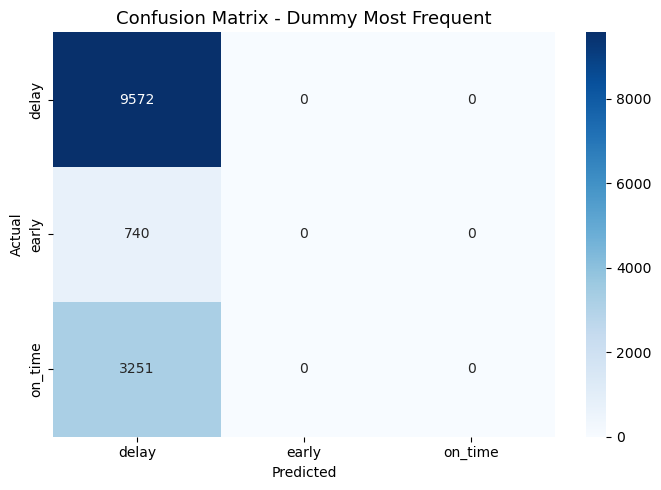

In [45]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
results.append(evaluate_model(dummy, X_val, y_val, 'Dummy Most Frequent'))

## Stratified 

=== Dummy Stratified ===
Accuracy:         0.563
F1 Macro:         0.335
F1 Delay:         0.709
F1 Early:         0.054
F1 On Time:       0.243
Recall Delay:     0.711
Recall Early:     0.053
Recall On Time:   0.242

              precision    recall  f1-score   support

       delay       0.71      0.71      0.71      9572
       early       0.06      0.05      0.05       740
     on_time       0.24      0.24      0.24      3251

    accuracy                           0.56     13563
   macro avg       0.34      0.34      0.34     13563
weighted avg       0.56      0.56      0.56     13563



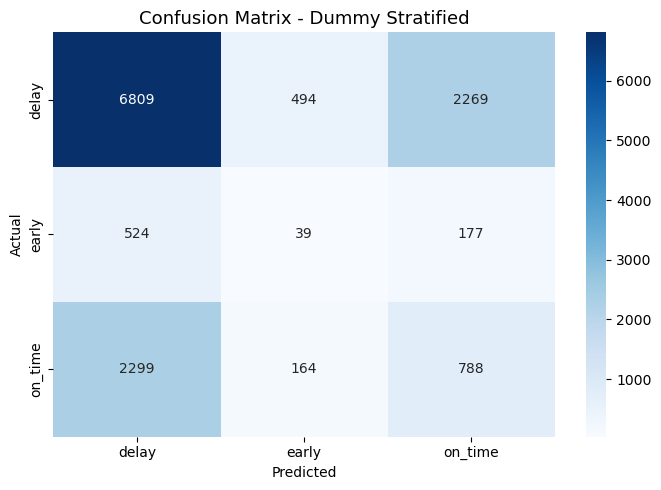

In [46]:
# Baseline 2 - Stratified (מנחש לפי התפלגות הקלאסים)
dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
dummy_strat.fit(X_train, y_train)
results.append(evaluate_model(dummy_strat, X_val, y_val, 'Dummy Stratified'))

# 2. Logistic Regression

=== Logistic Regression ===
Accuracy:         0.609
F1 Macro:         0.486
F1 Delay:         0.729
F1 Early:         0.213
F1 On Time:       0.515
Recall Delay:     0.610
Recall Early:     0.416
Recall On Time:   0.651

              precision    recall  f1-score   support

       delay       0.91      0.61      0.73      9572
       early       0.14      0.42      0.21       740
     on_time       0.43      0.65      0.51      3251

    accuracy                           0.61     13563
   macro avg       0.49      0.56      0.49     13563
weighted avg       0.75      0.61      0.65     13563



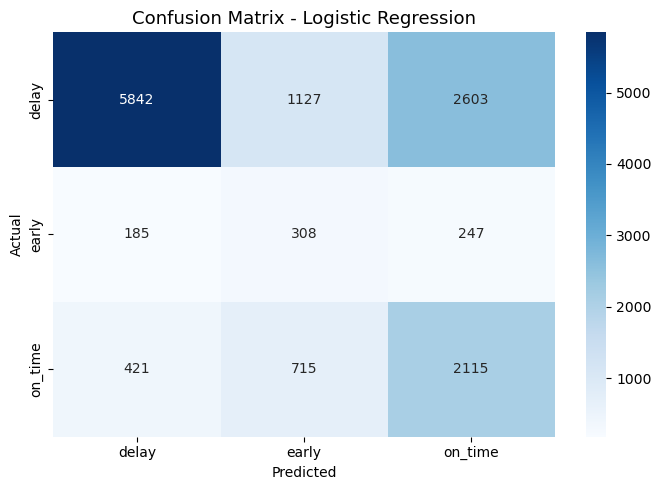

In [47]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
results.append(evaluate_model(lr, X_val, y_val, 'Logistic Regression'))

# 3. Random Forest

=== Random Forest ===
Accuracy:         0.783
F1 Macro:         0.635
F1 Delay:         0.865
F1 Early:         0.408
F1 On Time:       0.632
Recall Delay:     0.859
Recall Early:     0.412
Recall On Time:   0.645

              precision    recall  f1-score   support

       delay       0.87      0.86      0.86      9572
       early       0.40      0.41      0.41       740
     on_time       0.62      0.64      0.63      3251

    accuracy                           0.78     13563
   macro avg       0.63      0.64      0.64     13563
weighted avg       0.79      0.78      0.78     13563



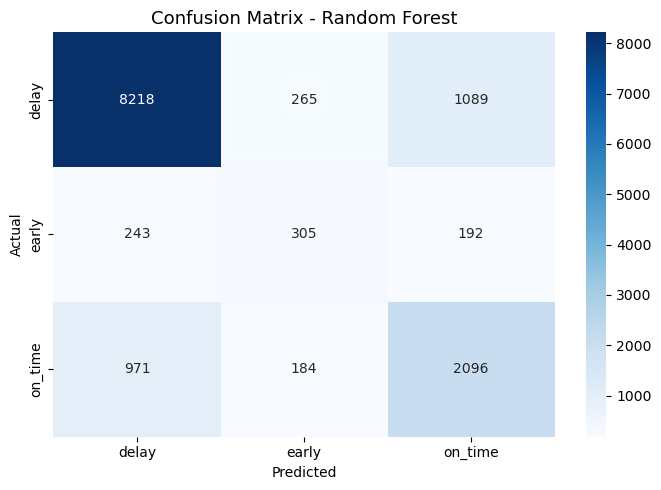

In [48]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model(rf, X_val, y_val, 'Random Forest'))

# 4. XGBoost

=== XGBoost ===
Accuracy:         0.832
F1 Macro:         0.685
F1 Delay:         0.899
F1 Early:         0.470
F1 On Time:       0.684
Recall Delay:     0.928
Recall Early:     0.350
Recall On Time:   0.659

              precision    recall  f1-score   support

       delay       0.87      0.93      0.90      9572
       early       0.72      0.35      0.47       740
     on_time       0.71      0.66      0.68      3251

    accuracy                           0.83     13563
   macro avg       0.77      0.65      0.68     13563
weighted avg       0.82      0.83      0.82     13563



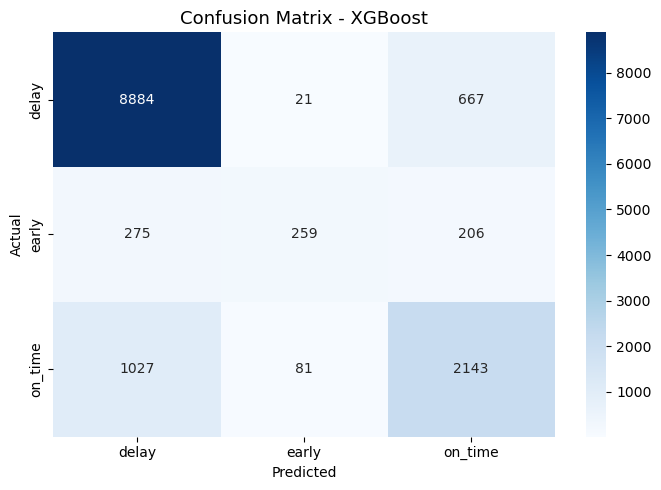

In [49]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                    subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train_enc)
y_pred_xgb = le.inverse_transform(xgb.predict(X_val))
results.append(evaluate_model_pred(y_val, y_pred_xgb, 'XGBoost'))

# 5. LightGBM

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008571 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4232
[LightGBM] [Info] Number of data points in the train set: 63365, number of used features: 27
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

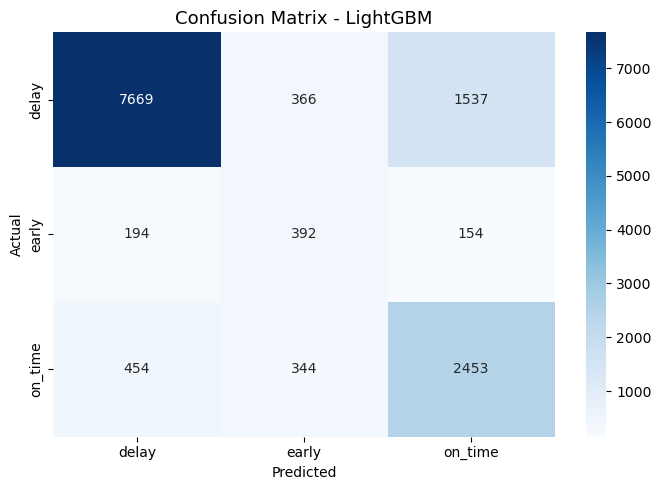

In [50]:
#!pip install lightgbm

from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                      random_state=42, class_weight='balanced', n_jobs=-1)
lgbm.fit(X_train, y_train)
results.append(evaluate_model(lgbm, X_val, y_val, 'LightGBM'))

# 6.  Model Comparison Summary

In [51]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1_Delay_Early', ascending=False)
print(results_df[['Model', 'Accuracy', 'F1_Macro', 'F1_Delay', 'F1_Early', 
                   'Recall_Delay', 'Recall_Early', 'F1_Delay_Early']])

                 Model  Accuracy  F1_Macro  F1_Delay  F1_Early  Recall_Delay  \
4              XGBoost  0.832117  0.684554  0.899281  0.470481      0.928124   
5             LightGBM  0.775197  0.648815  0.857398  0.425624      0.801191   
3        Random Forest  0.782939  0.635213  0.864871  0.408300      0.858546   
2  Logistic Regression  0.609378  0.485779  0.729338  0.213149      0.610322   
0  Dummy Most Frequent  0.705744  0.275830  0.827491  0.000000      1.000000   
1     Dummy Stratified  0.563002  0.335475  0.709123  0.054280      0.711346   

   Recall_Early  F1_Delay_Early  
4      0.350000        0.684881  
5      0.529730        0.641511  
3      0.412162        0.636585  
2      0.416216        0.471244  
0      0.000000        0.413745  
1      0.052703        0.381701  


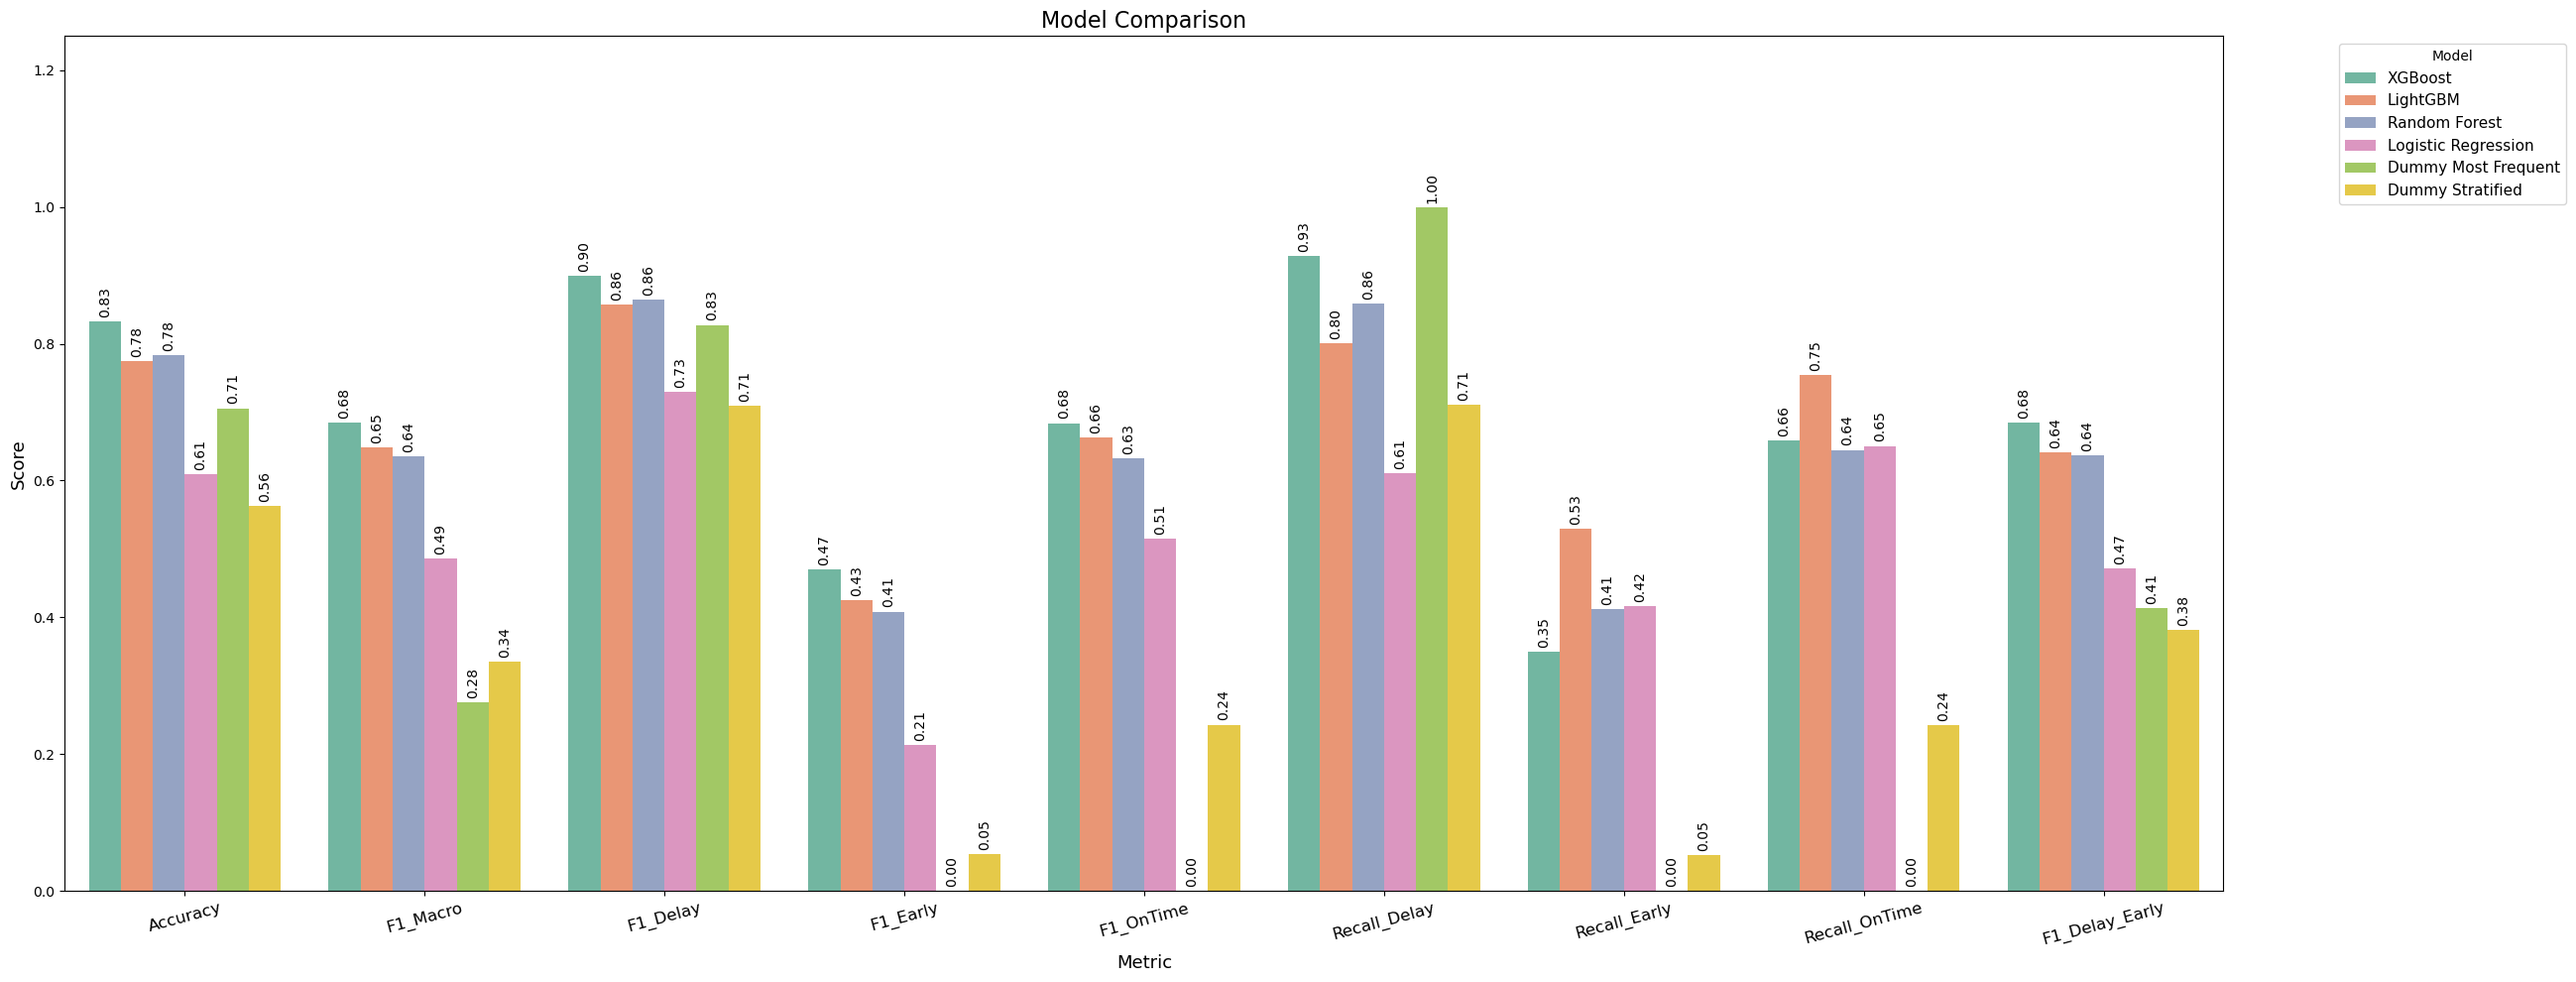

In [52]:
results_df = pd.DataFrame(results).sort_values(by='F1_Delay_Early', ascending=False)

metrics = ['Accuracy', 'F1_Macro', 'F1_Delay', 'F1_Early', 'F1_OnTime',
           'Recall_Delay', 'Recall_Early', 'Recall_OnTime', 'F1_Delay_Early']

plot_df = results_df[['Model'] + metrics].melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(26, 10))
ax = sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette='Set2')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10, rotation=90, padding=3)

plt.title('Model Comparison', fontsize=16)
plt.xlabel('Metric', fontsize=13)
plt.ylabel('Score', fontsize=13)
plt.ylim(0, 1.25)
plt.xticks(rotation=15, fontsize=12)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

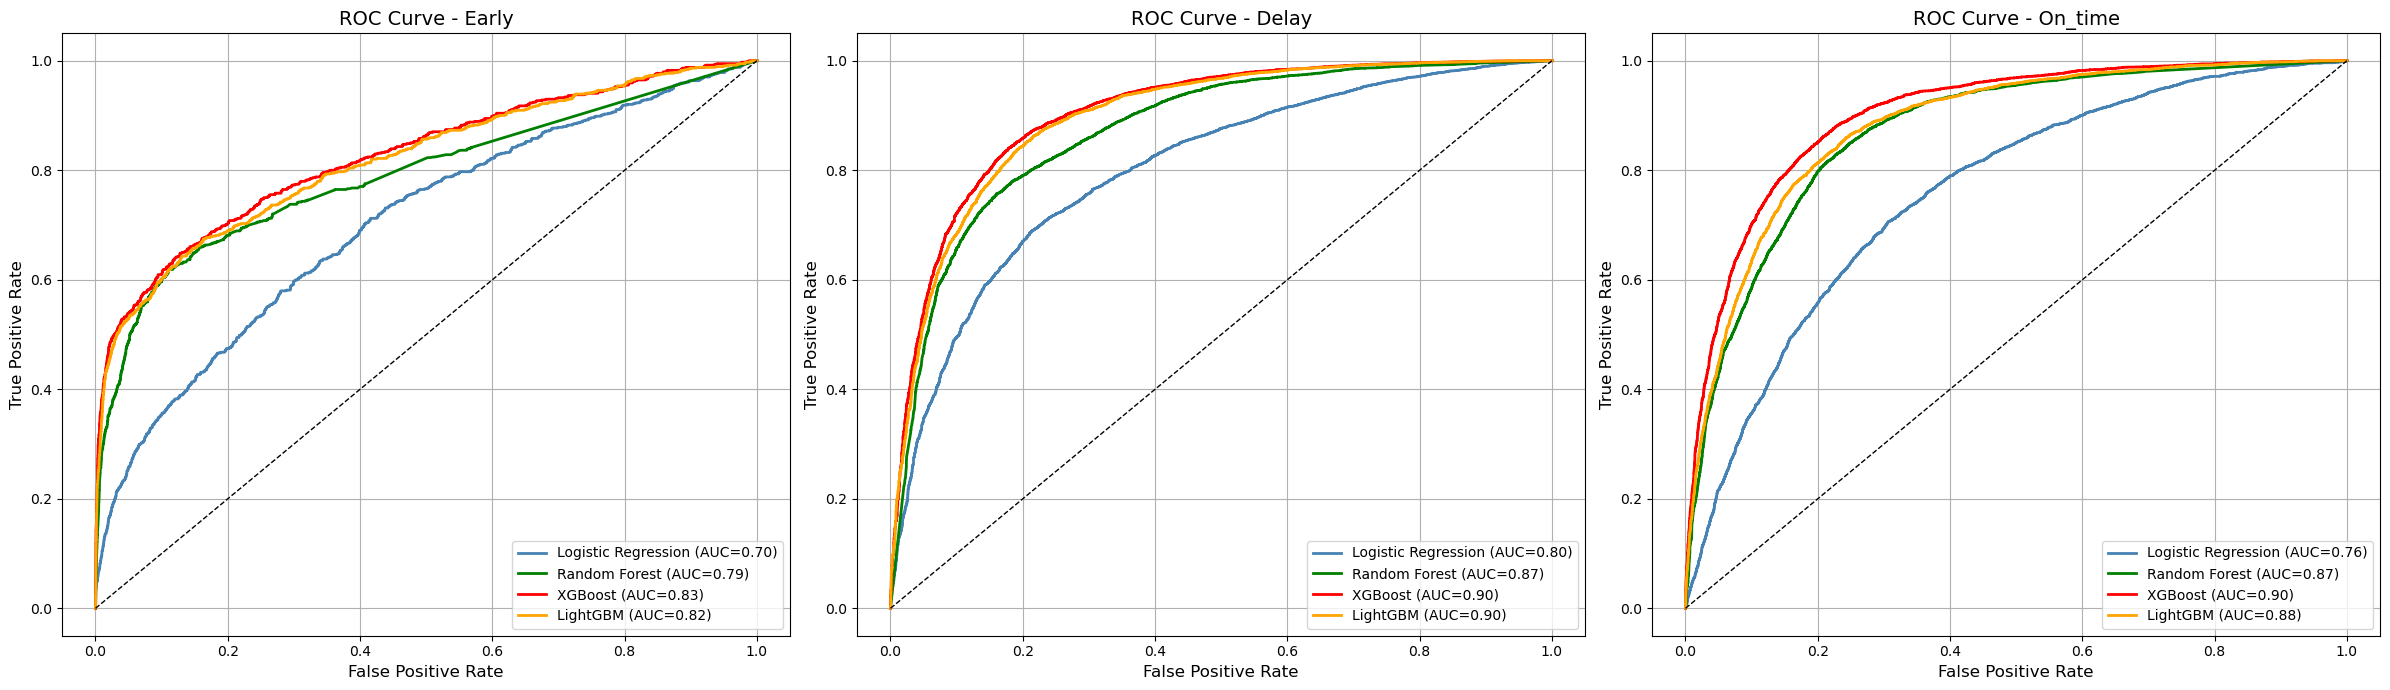

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

colors = {'Logistic Regression': 'steelblue', 
          'Random Forest': 'green', 
          'XGBoost': 'red', 
          'LightGBM': 'orange'}

for ax, target_class in zip(axes, ['early', 'delay', 'on_time']):
    class_idx = classes.index(target_class)
    
    for model_name, proba in models_proba.items():
        fpr, tpr, _ = roc_curve(y_val_bin[:, class_idx], proba[:, class_idx])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[model_name], linewidth=2,
                label=f'{model_name} (AUC={roc_auc:.2f})')
    
    ax.plot([0,1], [0,1], 'k--', linewidth=1)
    ax.set_title(f'ROC Curve - {target_class.capitalize()}', fontsize=14)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Check Overfitting

In [28]:


overfit_results = []
overfit_results.append(check_overfitting(lr,   X_train, y_train, X_val, y_val, 'Logistic Regression'))
overfit_results.append(check_overfitting(rf,   X_train, y_train, X_val, y_val, 'Random Forest'))
overfit_results.append(check_overfitting(xgb,  X_train, y_train, X_val, y_val, 'XGBoost', le=le))
overfit_results.append(check_overfitting(lgbm, X_train, y_train, X_val, y_val, 'LightGBM'))

overfit_df = pd.DataFrame(overfit_results)
print(overfit_df[['Model', 'Train Accuracy', 'Val Accuracy', 'Gap Accuracy', 
                   'Train F1 Macro', 'Val F1 Macro', 'Gap F1 Macro']].round(3))

                 Model  Train Accuracy  Val Accuracy  Gap Accuracy  \
0  Logistic Regression           0.610         0.609         0.001   
1        Random Forest           0.937         0.783         0.154   
2              XGBoost           0.858         0.832         0.026   
3             LightGBM           0.802         0.775         0.027   

   Train F1 Macro  Val F1 Macro  Gap F1 Macro  
0           0.488         0.486         0.002  
1           0.888         0.635         0.252  
2           0.737         0.685         0.053  
3           0.703         0.649         0.054  
